# **Homework 4**

**Name:** Ankit BhagwatiPrasad Dhandharia

**CWID:** 20033031

**Assignment Number & Name:** HW04_CART

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [19]:
# Loading the dataset
features_domain = ['Sample code number', 'Clump Thickness', 'Uniformity of Cell Size','Uniformity of Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin',
    'Normal Nucleoli', 'Mitoses', 'Class']
df = pd.read_csv('drive/MyDrive/breast-cancer-wisconsin.csv',header=0,names=features_domain, na_values="?")
df.head()

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2


In [20]:
# Removing missing values
df = df.dropna()

In [21]:
# Converting all data to integers
df = df.astype(int)

In [22]:
# Separate feature and label
features = df.drop(columns=["Sample code number", "Class"])
labels = df["Class"]

In [23]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

In [24]:
# Training decision tree model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [25]:
# Predict and evaluate
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print("Model Accuracy: ", accuracy)
print("Classification Report:", classification_report(y_test, predictions))
print("Confusion Matrix:", confusion_matrix(y_test, predictions))

Model Accuracy:  0.9197080291970803
Classification Report:               precision    recall  f1-score   support

           2       0.89      0.99      0.93        79
           4       0.98      0.83      0.90        58

    accuracy                           0.92       137
   macro avg       0.93      0.91      0.92       137
weighted avg       0.93      0.92      0.92       137

Confusion Matrix: [[78  1]
 [10 48]]


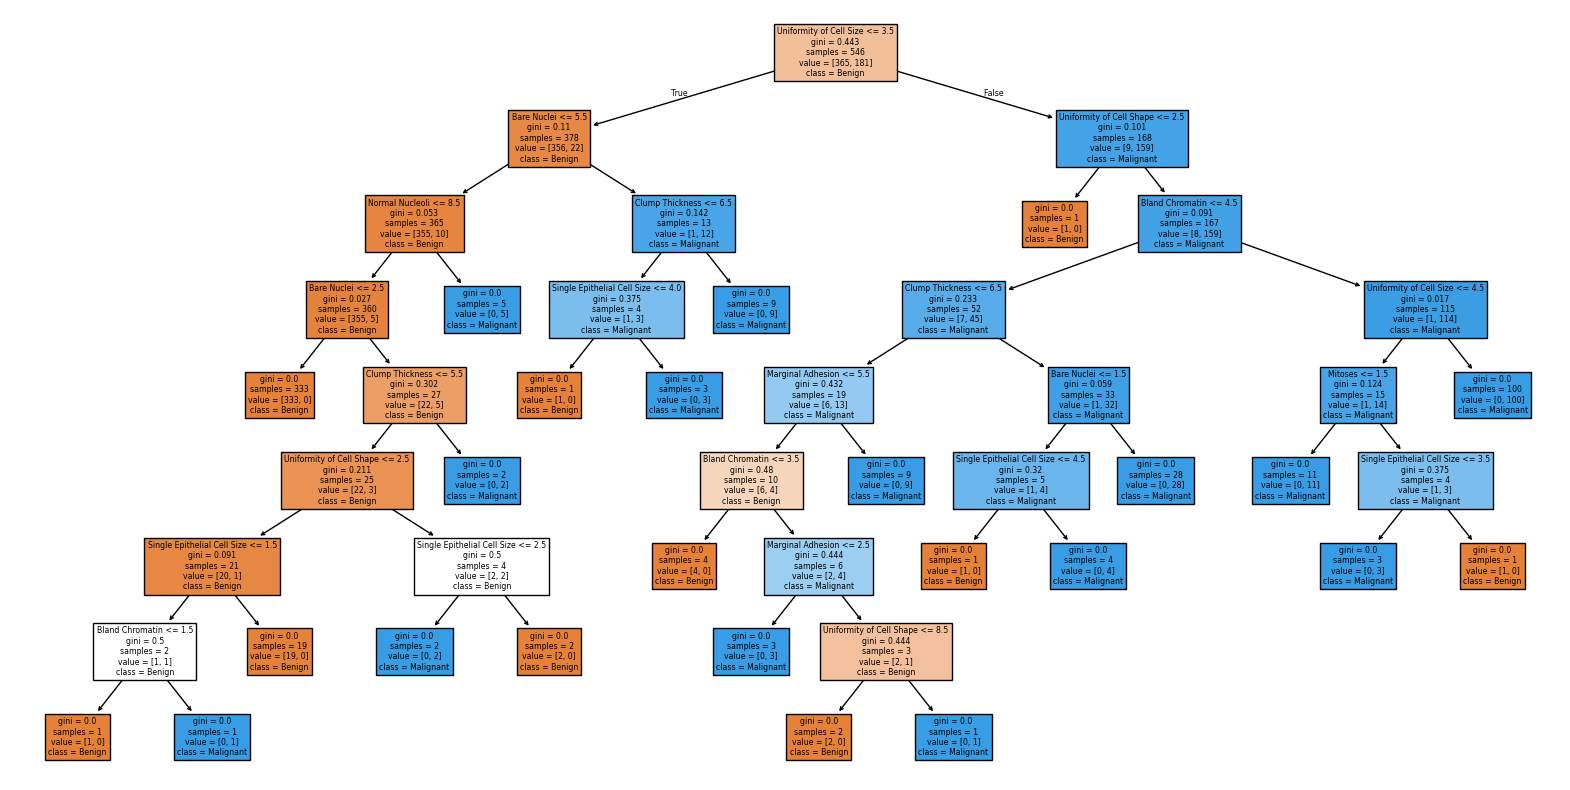

In [26]:
# Decision tree
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=features.columns, class_names=["Benign", "Malignant"], filled=True)
plt.show()